In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.wcs import WCS
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle

from copy import deepcopy
from glob import glob

In [25]:
! module list


Currently Loaded Modules:
  1) eth_proxy       3) gcc/12.2.0    5) texlive/20220321
  2) stack/2024-06   4) cuda/12.4.1   6) ffmpeg/6.0

Inactive Modules:
  1) python/3.11.6_cuda   2) code-server/4.12.0

 



In [118]:
raster_files = sorted(glob("../../src/full_detector/level2/2022/10/24/*.fits"))
raster_files

['../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T221629_V04_150995397-000.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T221815_V04_150995397-001.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222001_V04_150995397-002.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222148_V04_150995397-003.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222334_V04_150995397-004.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222519_V04_150995397-005.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222705_V04_150995397-006.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222851_V04_150995397-007.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T223037_V04_150995397-008.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spi

In [7]:
test_raster_cube = read_spice_l2_fits(raster_files[0])

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'. [astropy.wcs.wcs]


In [8]:
test_raster_cube.keys()

dict_keys(['Full SW 4:1 Focal Lossy', 'Full LW 4:1 Focal Lossy'])

In [9]:
test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape

(1, 1024, 1024, 1)

In [135]:
sw_data = np.ones((test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[1],
                   test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[2],
                   len(raster_files)))*np.nan

lw_data = np.ones((test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[1],
                     test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[2],
                     len(raster_files)))*np.nan

sw_wcs_list = []
lw_wcs_list = []
sw_meta_list = []
lw_meta_list = []
sw_wvl_list = []
lw_wvl_list = []

for ii, file_ in enumerate(raster_files):
    datacube_ = read_spice_l2_fits(file_)
    sw_data[:,:,ii] = datacube_['Full SW 4:1 Focal Lossy'].data[0,:,:,0]
    lw_data[:,:,ii] = datacube_['Full LW 4:1 Focal Lossy'].data[0,:,:,0]
    sw_wcs_list.append(datacube_['Full SW 4:1 Focal Lossy'].wcs)
    lw_wcs_list.append(datacube_['Full LW 4:1 Focal Lossy'].wcs)
    sw_meta_list.append(datacube_['Full SW 4:1 Focal Lossy'].meta)
    lw_meta_list.append(datacube_['Full LW 4:1 Focal Lossy'].meta)
    sw_wvl_list.append(datacube_['Full SW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
    lw_wvl_list.append(datacube_['Full LW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
sw_data = np.flip(sw_data, axis=-1)
lw_data = np.flip(lw_data, axis=-1)

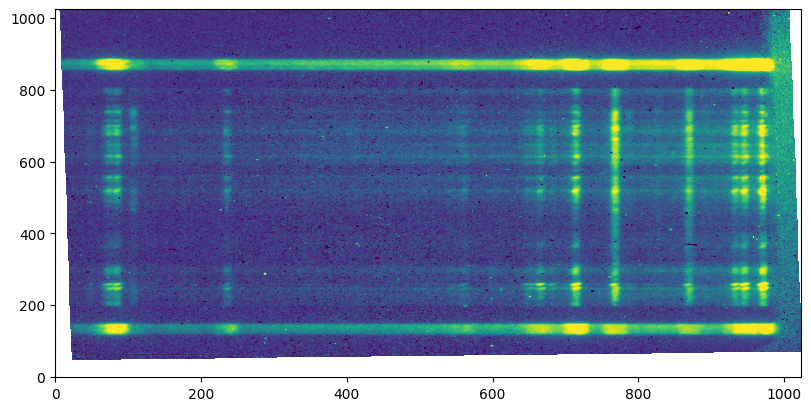

In [136]:
fig, ax = plt.subplots(figsize=(8,4),layout="constrained")
ax.imshow(sw_data[:,:,0].T, origin='lower',
          norm=ImageNormalize(vmin=np.nanpercentile(sw_data[:,:,0], 1),
                                vmax=np.nanpercentile(sw_data[:,:,0], 99),
                                stretch=AsinhStretch()),
                                aspect='auto')

/scratch/tmp.24446205.zhuyin/ipykernel_1748450/830493919.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,:,0], axis=1), where='mid')


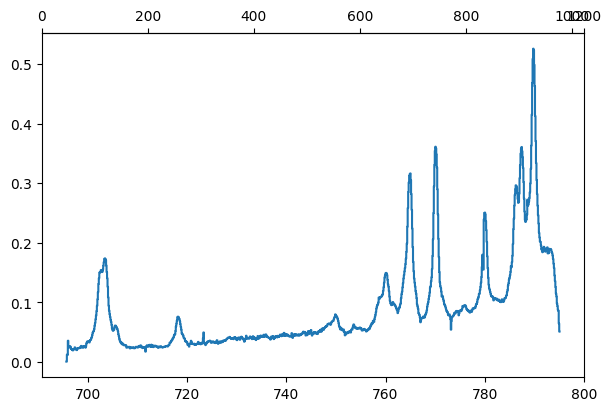

In [137]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,:,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))

/scratch/tmp.24446205.zhuyin/ipykernel_1748450/892070075.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,:,0], axis=1), where='mid')


(0.05, 0.6)

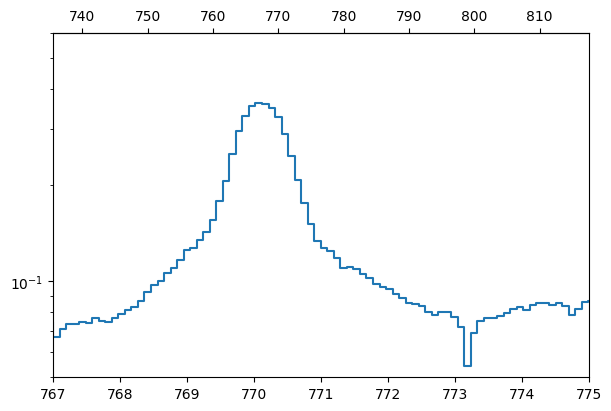

In [138]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,:,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# _ = secax.set_xticks([0,200,400,600,800,1000])

ax.set_xlim(767,775)
ax.set_yscale("log")
ax.set_ylim(5e-2,0.6)

Ne VIII 780 is blended with two O IV lines at the blue wing

/scratch/tmp.24446205.zhuyin/ipykernel_1748450/635637407.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,:,0], axis=1), where='mid')


(779.0, 781.0)

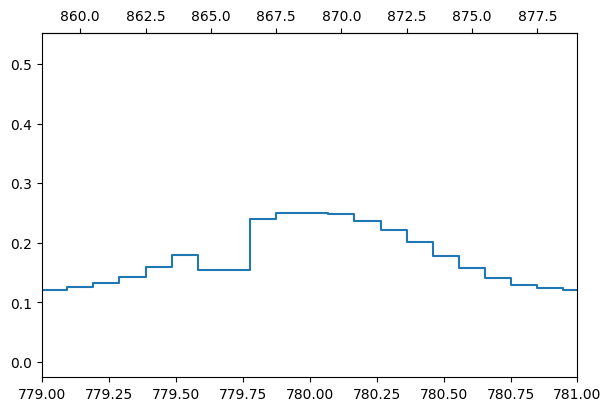

In [139]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,:,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# _ = secax.set_xticks([0,200,400,600,800,1000])

ax.set_xlim(779,781)

N IV 765 has two N III blending at the blue wing (763.334, 764.351)

/scratch/tmp.24446205.zhuyin/ipykernel_1748450/1872633787.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,:,0], axis=1), where='mid')


(0.08, 0.5)

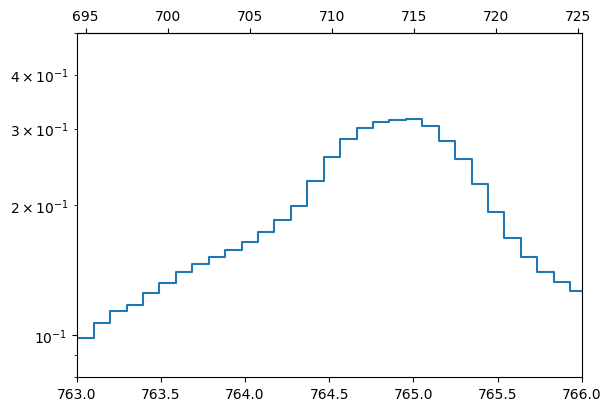

In [140]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,:,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# _ = secax.set_xticks([0,200,400,600,800,1000])

ax.set_xlim(763,766)
ax.set_yscale("log")
ax.set_ylim(8e-2, 0.5)

In [141]:
print(770.428 - 769.355)
print(770.428 - 772.260)

1.072999999999979
-1.8319999999999936


In [142]:
def func_NeVIII_770(x, wvl_770, int_769, int_770, int_772, wid_770, wid_772, a, b):
    return gaussian(x, wvl_770-1.073, int_769, wid_772) + \
           gaussian(x, wvl_770, int_770, wid_770) + \
           gaussian(x, wvl_770+1.832, int_772, wid_772) + \
           a*x + b

In [154]:
test_fit_NeVIII_wvl = sw_wvl_list[0][735:799]
test_fit_NeVIII_data = np.nanmean(sw_data[:,:,-1], axis=1)[735:799]

/scratch/tmp.24446205.zhuyin/ipykernel_1748450/3075821472.py:2: RuntimeWarning: Mean of empty slice
  test_fit_NeVIII_data = np.nanmean(sw_data[:,:,-1], axis=1)[735:799]


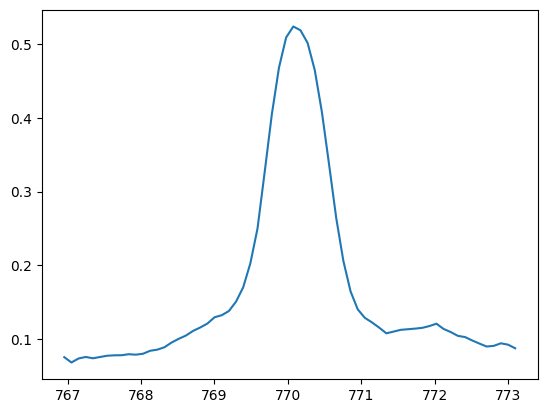

In [155]:
plt.plot(test_fit_NeVIII_wvl, test_fit_NeVIII_data)

In [156]:
test_fit_NeVIII_model = SpectrumFitSingle(data=test_fit_NeVIII_data,
                                        wvl=test_fit_NeVIII_wvl,
                                        err=None,
                                        custom_func=func_NeVIII_770,
                                        custom_init=[770.428, 0.1, 0.4, 0.1, 0.7, 0.7, 0, 0.5],)

test_fit_NeVIII_model.run_lse()

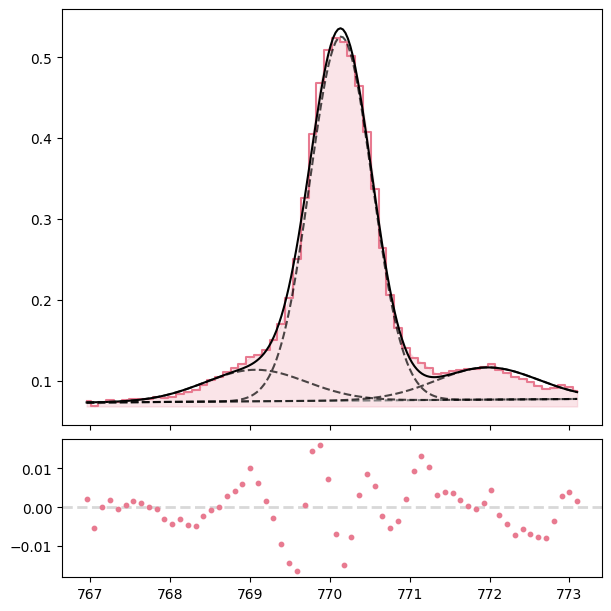

In [157]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,6), layout="constrained",
                            gridspec_kw={'height_ratios': [3,1]}, sharex=True)

test_fit_NeVIII_wvl_plot = np.linspace(test_fit_NeVIII_wvl[0], test_fit_NeVIII_wvl[-1], 200)

ax1.step(test_fit_NeVIII_wvl, test_fit_NeVIII_data, where='mid', color="#E87A90")
ax1.fill_between(test_fit_NeVIII_wvl, np.nanmin(test_fit_NeVIII_data), test_fit_NeVIII_data, color="#E87A90", alpha=0.2)
ax1.plot(test_fit_NeVIII_wvl_plot, func_NeVIII_770(test_fit_NeVIII_wvl_plot, *test_fit_NeVIII_model.custom_fit),
        color="black")

ax1.plot(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model.custom_fit[7],
        color="grey", linestyle="dashed")

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model.custom_fit[0]-1.073,
                                           test_fit_NeVIII_model.custom_fit[1],
                                           test_fit_NeVIII_model.custom_fit[5]) + \
         test_fit_NeVIII_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model.custom_fit[0],
                                           test_fit_NeVIII_model.custom_fit[2],
                                           test_fit_NeVIII_model.custom_fit[4]) + \
         test_fit_NeVIII_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model.custom_fit[0]+1.832,
                                           test_fit_NeVIII_model.custom_fit[3],
                                           test_fit_NeVIII_model.custom_fit[5]) + \
         test_fit_NeVIII_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax2.scatter(test_fit_NeVIII_wvl, test_fit_NeVIII_data - func_NeVIII_770(test_fit_NeVIII_wvl, *test_fit_NeVIII_model.custom_fit),
            s=10, color="#E87A90")
ax2.axhline(0, color="grey", lw=2, ls="--", alpha=0.3, zorder=0)

In [158]:
def double_gaussian(x, line_wvl, int_total, fwhm, alpha, beta):
    return gaussian(x, line_wvl, int_total, fwhm) + \
    gaussian(x, line_wvl, alpha*int_total, beta*fwhm)

def func_NeVIII_770_dg(x, wvl_770, int_769, int_770, int_772,
                       wid_770, wid_772,
                       a, b, alpha, beta):
    return double_gaussian(x, wvl_770-1.073, int_769, wid_772, alpha, beta) + \
           double_gaussian(x, wvl_770, int_770, wid_770, alpha, beta) + \
           double_gaussian(x, wvl_770+1.832, int_772, wid_772, alpha, beta) + \
           a*x + b

In [159]:
test_fit_NeVIII_dg_model = SpectrumFitSingle(wvl=test_fit_NeVIII_wvl,
                                        data=test_fit_NeVIII_data,
                                        custom_func=func_NeVIII_770_dg,
                                        custom_init=[*test_fit_NeVIII_model.custom_fit, 0.2, 3],
                                        err=None)

test_fit_NeVIII_dg_model.run_lse()

In [160]:
print(f"Ne VIII 770 wvl: {test_fit_NeVIII_dg_model.custom_fit[0]:.3f}",
      f"Mg VIII 769 wvl: {test_fit_NeVIII_dg_model.custom_fit[0] - 1.073:.3f}", 
      f"Mg VIII 772 wvl: {test_fit_NeVIII_dg_model.custom_fit[0] + 1.832:.3f}",
      f"Ne VIII 770 vel: {(test_fit_NeVIII_dg_model.custom_fit[0]/770.428 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Mg VIII 769 vel: {((test_fit_NeVIII_dg_model.custom_fit[0] - 1.073)/769.355 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Mg VIII 772 vel: {((test_fit_NeVIII_dg_model.custom_fit[0] + 1.832)/772.260 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Ne VIII 770 int: {test_fit_NeVIII_dg_model.custom_fit[2]:.3f}",
      f"Mg VIII 769 int: {test_fit_NeVIII_dg_model.custom_fit[1]:.3f}",
      f"Mg VIII 772 int: {test_fit_NeVIII_dg_model.custom_fit[3]:.3f}",
      f"Ne VIII 770 FWHM: {test_fit_NeVIII_dg_model.custom_fit[4]:.3f}",
      f"Mg VIII FWHM: {test_fit_NeVIII_dg_model.custom_fit[5]:.3f}",
      f"Continuum Slope: {test_fit_NeVIII_dg_model.custom_fit[6]:.3e}",
      f"Continuum Intercept: {test_fit_NeVIII_dg_model.custom_fit[7]:.3f}",
      f"Secondary Gaussian Intensity Ratio {test_fit_NeVIII_dg_model.custom_fit[8]:.3f}",
      f"Secondary Gaussian FWHM Ratio {test_fit_NeVIII_dg_model.custom_fit[9]:.3f}",
      sep="\n")

Ne VIII 770 wvl: 770.126
Mg VIII 769 wvl: 769.053
Mg VIII 772 wvl: 771.958
Ne VIII 770 vel: -117.4
Mg VIII 769 vel: -117.6
Mg VIII 772 vel: -117.1
Ne VIII 770 int: 0.405
Mg VIII 769 int: 0.016
Mg VIII 772 int: 0.014
Ne VIII 770 FWHM: 0.882
Mg VIII FWHM: 0.692
Continuum Slope: 2.888e-03
Continuum Intercept: -2.153
Secondary Gaussian Intensity Ratio 0.389
Secondary Gaussian FWHM Ratio 4.801


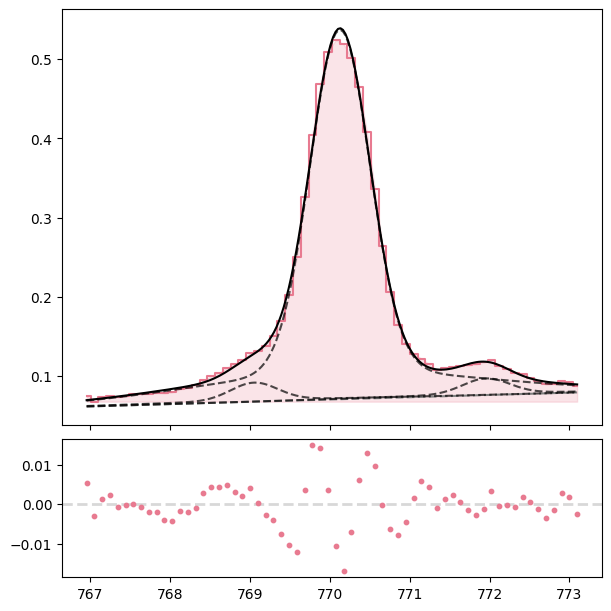

In [161]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,6), layout="constrained",
                            gridspec_kw={'height_ratios': [3,1]}, sharex=True)

ax1.step(test_fit_NeVIII_wvl, test_fit_NeVIII_data, where='mid', color="#E87A90")
ax1.fill_between(test_fit_NeVIII_wvl, np.nanmin(test_fit_NeVIII_data), test_fit_NeVIII_data, color="#E87A90", alpha=0.2)

ax1.plot(test_fit_NeVIII_wvl_plot, func_NeVIII_770_dg(test_fit_NeVIII_wvl_plot, *test_fit_NeVIII_dg_model.custom_fit),
        color="black")

ax1.plot(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_dg_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_dg_model.custom_fit[7],
        color="grey", linestyle="dashed")

ax1.plot(test_fit_NeVIII_wvl_plot, double_gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_dg_model.custom_fit[0]-1.073,
                                           test_fit_NeVIII_dg_model.custom_fit[1],
                                           test_fit_NeVIII_dg_model.custom_fit[5],
                                           test_fit_NeVIII_dg_model.custom_fit[8],
                                           test_fit_NeVIII_dg_model.custom_fit[9]) + \
         test_fit_NeVIII_dg_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_dg_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, double_gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_dg_model.custom_fit[0],
                                           test_fit_NeVIII_dg_model.custom_fit[2],
                                           test_fit_NeVIII_dg_model.custom_fit[4],
                                           test_fit_NeVIII_dg_model.custom_fit[8],
                                           test_fit_NeVIII_dg_model.custom_fit[9]) + \
         test_fit_NeVIII_dg_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_dg_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, double_gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_dg_model.custom_fit[0]+1.832,
                                           test_fit_NeVIII_dg_model.custom_fit[3],
                                           test_fit_NeVIII_dg_model.custom_fit[5],
                                           test_fit_NeVIII_dg_model.custom_fit[8],
                                           test_fit_NeVIII_dg_model.custom_fit[9]) + \
         test_fit_NeVIII_dg_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_dg_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax2.scatter(test_fit_NeVIII_wvl, test_fit_NeVIII_data - func_NeVIII_770_dg(test_fit_NeVIII_wvl, *test_fit_NeVIII_dg_model.custom_fit),
            s=10, color="#E87A90")      
ax2.axhline(0, color="grey", lw=2, ls="--", alpha=0.3, zorder=0)

In [162]:
cdelt1 = np.sqrt(np.sum((sw_wcs_list[0].wcs.crval[:2] - sw_wcs_list[1].wcs.crval[:2])**2))*3600
cdelt1

3.523144994791964

In [163]:
cdelt2 = sw_wcs_list[0].wcs.cdelt[1]*3600
cdelt2

1.098

In [164]:
NeVIII_770_intmap = np.nanmean(sw_data[755:780,:,:], axis=0)
NIV_765_intmap = np.nanmean(sw_data[705:725,:,:], axis=0)

/scratch/tmp.24446205.zhuyin/ipykernel_1748450/2019181606.py:1: RuntimeWarning: Mean of empty slice
  NeVIII_770_intmap = np.nanmean(sw_data[755:780,:,:], axis=0)
/scratch/tmp.24446205.zhuyin/ipykernel_1748450/2019181606.py:2: RuntimeWarning: Mean of empty slice
  NIV_765_intmap = np.nanmean(sw_data[705:725,:,:], axis=0)


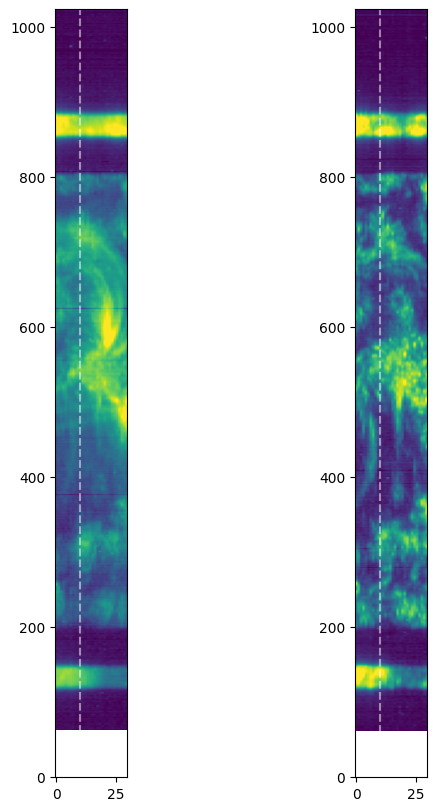

In [165]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,8),layout="constrained")
ax1.imshow(NeVIII_770_intmap, origin='lower',
           norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_770_intmap, 1),
                               vmax=np.nanpercentile(NeVIII_770_intmap, 99),
                               stretch=AsinhStretch()), aspect=cdelt2/cdelt1)

ax2.imshow(NIV_765_intmap, origin='lower',
              norm=ImageNormalize(vmin=np.nanpercentile(NIV_765_intmap, 1),
                                  vmax=np.nanpercentile(NIV_765_intmap, 99),
                                  stretch=AsinhStretch()), aspect=cdelt2/cdelt1)

for ax_ in (ax1,ax2):
    ax_.axvline(10, color='w', linestyle='--', alpha=0.5)